In [1]:
import pandas as pd
import numpy as np

In [2]:
users = pd.read_csv('takehome_users.csv', encoding='latin1')
engagement = pd.read_csv('takehome_user_engagement.csv', encoding='latin1')

In [3]:
print(users.shape)
print(engagement.shape)

(12000, 10)
(207917, 3)


In [4]:
users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [5]:
engagement.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [6]:
users.isna().sum()

object_id                        0
creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time    3177
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
invited_by_user_id            5583
dtype: int64

In [7]:
engagement.isna().sum()

time_stamp    0
user_id       0
visited       0
dtype: int64

In [8]:
# renaming columns so they're easier for me to understand and work with

user_rename = {
    'object_id': 'user_id',
    'creation_time': 'account_created_time',
    'last_session_creation_time': 'last_login_time',
    'opted_in_to_mailing_list': 'mailing_list',
    'enabled_for_marketing_drip': 'marketing_drip',
    'invited_by_user_id': 'invited_by'}

engagement_rename = {
    'time_stamp': 'login_date',
    'visited': 'logged_in'}

In [9]:
users = users.rename(columns=user_rename)
engagement = engagement.rename(columns=engagement_rename)

print(users.info())
print('-----------')
print(engagement.info())

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               12000 non-null  int64  
 1   account_created_time  12000 non-null  str    
 2   name                  12000 non-null  str    
 3   email                 12000 non-null  str    
 4   creation_source       12000 non-null  str    
 5   last_login_time       8823 non-null   float64
 6   mailing_list          12000 non-null  int64  
 7   marketing_drip        12000 non-null  int64  
 8   org_id                12000 non-null  int64  
 9   invited_by            6417 non-null   float64
dtypes: float64(2), int64(4), str(4)
memory usage: 937.6 KB
None
-----------
<class 'pandas.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   login_date  207917 non-null  

In [10]:
# date time conversions

users['account_created_time'] = pd.to_datetime(users['account_created_time'])

engagement['login_date'] = pd.to_datetime(engagement['login_date'])

users['last_login_time'] = pd.to_datetime(users['last_login_time'], unit='s')

In [11]:
engagement['logged_in'].value_counts()

logged_in
1    207917
Name: count, dtype: int64

In [12]:
pd.crosstab(
    users['mailing_list'],
    users['marketing_drip'])

marketing_drip,0,1
mailing_list,,
0,8556,450
1,1652,1342


In [13]:
users['creation_source'].value_counts()

creation_source
ORG_INVITE            4254
GUEST_INVITE          2163
PERSONAL_PROJECTS     2111
SIGNUP                2087
SIGNUP_GOOGLE_AUTH    1385
Name: count, dtype: int64

In [14]:
engagement['login_date'] = pd.to_datetime(engagement['login_date']).dt.normalize()

engagement = engagement.drop_duplicates(
    subset=['user_id', 'login_date']).sort_values(['user_id', 'login_date'])

### Calculating adoption based on engagement table

In [15]:
# creating a function to check login dates for a single user and mark as adopted

def adopted(login_dates):
    dates = login_dates.sort_values().reset_index(drop=True)

    for i in range(len(dates) - 2): # loop through every possible group of 3 consecutive dates in the login list
        if dates[i + 2] - dates[i] <= pd.Timedelta(days=6): # is the third login no more than 6 days after the first login?
            return 1

    return 0

In [16]:
adoption = (
    engagement.groupby('user_id')['login_date']
    .apply(adopted)
    .rename('adopted')
    .reset_index())

### Merging adoption onto user table

In [17]:
users = users.merge(
    adoption,
    on='user_id',
    how='left')

In [18]:
users['adopted'] = users['adopted'].fillna(0).astype(int)

In [19]:
users['adopted'].value_counts(normalize=True)

adopted
0    0.8665
1    0.1335
Name: proportion, dtype: float64

85% of users haven't adopted (login at least 3 separate days in a given week), only 13% of users have.

### EDA

In [20]:
users.groupby('creation_source')['adopted'].mean().sort_values(ascending=False)

creation_source
SIGNUP_GOOGLE_AUTH    0.167509
GUEST_INVITE          0.166436
SIGNUP                0.140393
ORG_INVITE            0.129995
PERSONAL_PROJECTS     0.077688
Name: adopted, dtype: float64

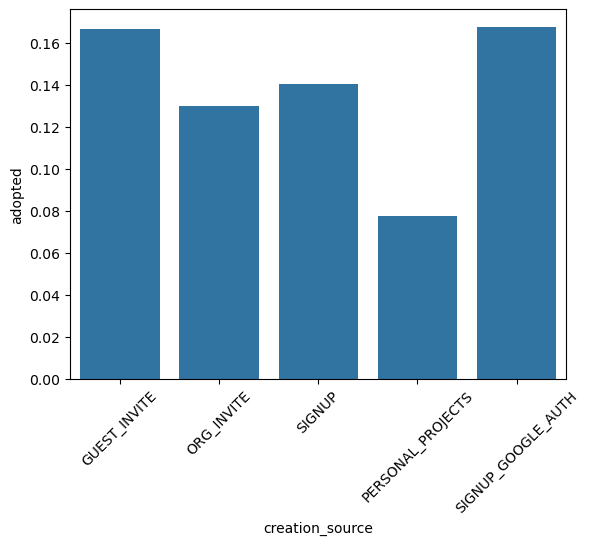

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=users, x='creation_source', y='adopted', errorbar=None)
plt.xticks(rotation=45)
plt.show()

In [22]:
users.groupby('mailing_list')['adopted'].mean()

mailing_list
0    0.131912
1    0.138277
Name: adopted, dtype: float64

In [23]:
users.groupby('marketing_drip')['adopted'].mean()

marketing_drip
0    0.132837
1    0.137277
Name: adopted, dtype: float64

In [24]:
users['was_invited'] = users['invited_by'].notna().astype(int)

In [25]:
users.groupby('was_invited')['adopted'].mean()

was_invited
0    0.123410
1    0.142278
Name: adopted, dtype: float64

In [26]:
users.groupby('org_id')['adopted'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)

,mean,count
org_id,,
387,0.583333,12
235,0.461538,13
270,0.428571,14
399,0.384615,13
400,0.375000,8
415,0.375000,16
392,0.375000,16
117,0.363636,22
345,0.357143,14


In [27]:
# calculating the age of the account to see how that might affect adoption rates
users['account_age_days'] = (users['last_login_time'] - users['account_created_time']).dt.days

In [28]:
users.groupby('adopted')['account_age_days'].describe().T

adopted,0,1
count,7221.000000,1602.000000
mean,5.760283,300.200999
std,16.324531,205.754715
min,0.000000,4.000000
25%,0.000000,129.000000
50%,1.000000,250.000000
75%,2.000000,469.500000
max,251.000000,729.000000


I can't tell if someone will be a REGULAR based on their most recent visit or how long they've been a customer, so I need to make sure not to include account age and last login time in the model data. 

### Logistic Regression

In [29]:
# based on EDA, these are the features I want to look at to determine whether someone will adopt or not
features = [
    'creation_source', 'mailing_list','marketing_drip',
    'org_id','was_invited']

In [30]:
model_df = users[
    ['creation_source','mailing_list','marketing_drip',
        'org_id','was_invited','adopted']].copy()

In [31]:
# binary colums for categorical features so they can be used by the model
model_df = pd.get_dummies(
    model_df,
    columns=['creation_source', 'org_id'],
    drop_first=True)

In [32]:
X = model_df.drop(columns='adopted')
y = model_df['adopted']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
X_train.shape, X_test.shape

((9600, 423), (2400, 423))

In [35]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
y_pred = log_model.predict(X_test)

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      2080
           1       0.00      0.00      0.00       320

    accuracy                           0.87      2400
   macro avg       0.43      0.50      0.46      2400
weighted avg       0.75      0.87      0.80      2400



C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [38]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8666666666666667

In [39]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_model.coef_[0]})

In [40]:
coef_df.sort_values('coefficient', ascending=False).head(10)

,feature,coefficient
393,org_id_387,1.769320
241,org_id_235,1.487018
324,org_id_318,1.292250
123,org_id_117,1.240606
183,org_id_177,1.125893
276,org_id_270,1.102544
387,org_id_381,1.069274
88,org_id_82,1.058241
312,org_id_306,1.018872
405,org_id_399,0.976922


In [41]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced')

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [42]:
y_pred = log_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.60      0.71      2080
           1       0.16      0.50      0.24       320

    accuracy                           0.58      2400
   macro avg       0.52      0.55      0.48      2400
weighted avg       0.79      0.58      0.65      2400



The Logistic Regression scores are very low, meaning the model is mostly predicting that users don't adopt (playing it safe). 
The strongest coefficients are 393, 241, and 324. Using the actual organizations is really misleading and confusing, so I need to adjust my data so I can base the model / prediction on organization size rather than a specific organization. 

In [43]:
users['org_size'] = users.groupby('org_id')['user_id'].transform('count')

In [44]:
model_df = users[
    [
        'creation_source','mailing_list','marketing_drip',
        'was_invited','org_size','adopted']].copy()

In [45]:
model_df = pd.get_dummies(
    model_df,
    columns=['creation_source'],
    drop_first=True)

In [46]:
X = model_df.drop(columns='adopted')
y = model_df['adopted']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [48]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced')

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [49]:
y_pred = log_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.40      0.55      2080
           1       0.16      0.75      0.26       320

    accuracy                           0.44      2400
   macro avg       0.54      0.57      0.41      2400
weighted avg       0.81      0.44      0.51      2400



In [50]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_model.coef_[0]}).sort_values('coefficient', ascending=False)

coef_df # was invited is 'guest invite'

,feature,coefficient
7,creation_source_SIGNUP_GOOGLE_AUTH,0.313082
2,was_invited,0.308441
6,creation_source_SIGNUP,0.109398
0,mailing_list,0.036863
3,org_size,-0.005229
1,marketing_drip,-0.032616
4,creation_source_ORG_INVITE,-0.247053
5,creation_source_PERSONAL_PROJECTS,-0.549402


### Random Forest Model

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:
rf_pred = rf_model.predict(X_test)

In [53]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.68      0.77      2080
           1       0.15      0.38      0.22       320

    accuracy                           0.64      2400
   macro avg       0.52      0.53      0.49      2400
weighted avg       0.78      0.64      0.69      2400



In [54]:
importance_df_0 = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_}).sort_values('importance', ascending=False)

importance_df_0

,feature,importance
3,org_size,0.889640
5,creation_source_PERSONAL_PROJECTS,0.034426
0,mailing_list,0.019419
1,marketing_drip,0.018503
4,creation_source_ORG_INVITE,0.013187
2,was_invited,0.009902
7,creation_source_SIGNUP_GOOGLE_AUTH,0.008271
6,creation_source_SIGNUP,0.006652


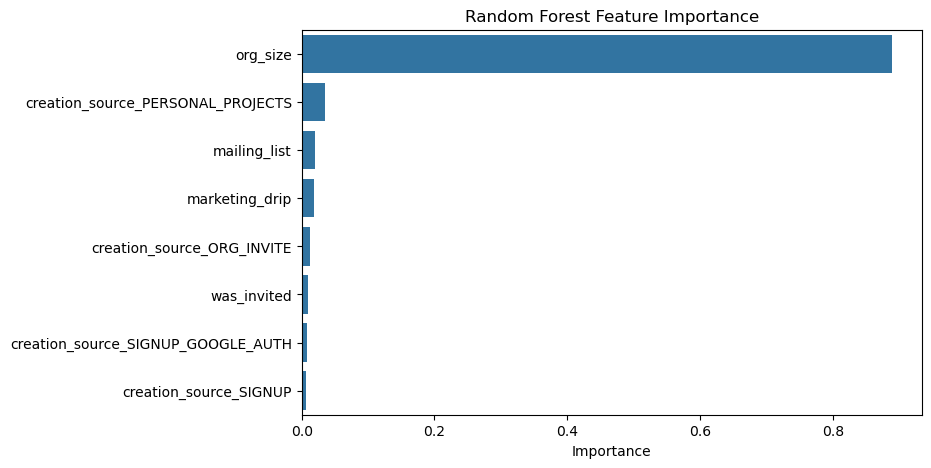

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance_df_0,
    x='importance',
    y='feature')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('')
plt.show()

The fact that organization size has such a high importance on predictions, I'd want to investigate further.

In [56]:
users.groupby('adopted')['org_size'].describe()

,count,mean,std,min,25%,50%,75%,max
adopted,,,,,,,,
0,10398.0,57.193210,66.266323,2.0,21.0,30.0,57.0,319.0
1,1602.0,41.577403,44.641923,7.0,19.0,27.0,42.0,319.0


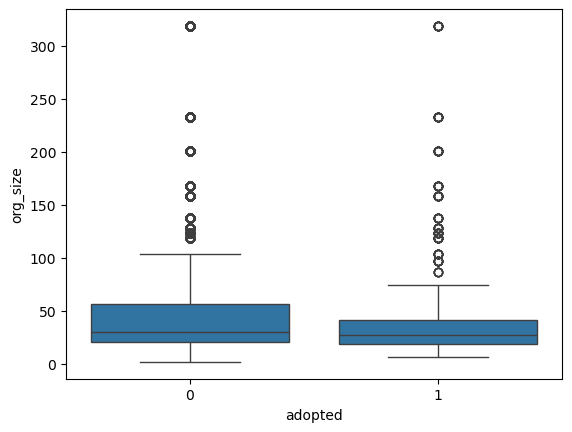

In [57]:
sns.boxplot(
    data=users,
    x='adopted',
    y='org_size')

plt.show()

### Adjusted RF model

In [58]:
# checking to see how RF performs when we drop org size
X_rf = X.drop(columns='org_size')

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [59]:
rf_model_1 = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42)

rf_model_1.fit(X_train_rf, y_train_rf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [60]:
rf_pred_1 = rf_model_1.predict(X_test_rf)

print(classification_report(y_test_rf, rf_pred_1))

              precision    recall  f1-score   support

           0       0.90      0.50      0.64      2080
           1       0.16      0.62      0.26       320

    accuracy                           0.52      2400
   macro avg       0.53      0.56      0.45      2400
weighted avg       0.80      0.52      0.59      2400



In [63]:
importance_df_1 = pd.DataFrame({
    'feature': X_rf.columns,
    'importance': rf_model_1.feature_importances_}).sort_values('importance', ascending=False)

importance_df_1

,feature,importance
4,creation_source_PERSONAL_PROJECTS,0.466121
6,creation_source_SIGNUP_GOOGLE_AUTH,0.109314
2,was_invited,0.102313
3,creation_source_ORG_INVITE,0.097328
1,marketing_drip,0.086888
0,mailing_list,0.076348
5,creation_source_SIGNUP,0.061689


In [64]:
log_pred = log_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

rf_pred_0 = rf_model_1.predict(X_test_rf)

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def model_scores(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)}

In [67]:
results = pd.DataFrame({
    'Logistic Regression': model_scores(y_test, log_pred),
    'RF with org_size': model_scores(y_test, rf_pred),
    'RF without org_size': model_scores(y_test_rf, rf_pred_1)}).T

results.round(2)

,accuracy,precision,recall,f1
Logistic Regression,0.44,0.16,0.75,0.26
RF with org_size,0.64,0.15,0.38,0.22
RF without org_size,0.52,0.16,0.62,0.26


Logistic regression is the most useful model since it identified 75% of adopted users (stronger than other models). But overall, every model has low precision scores. 

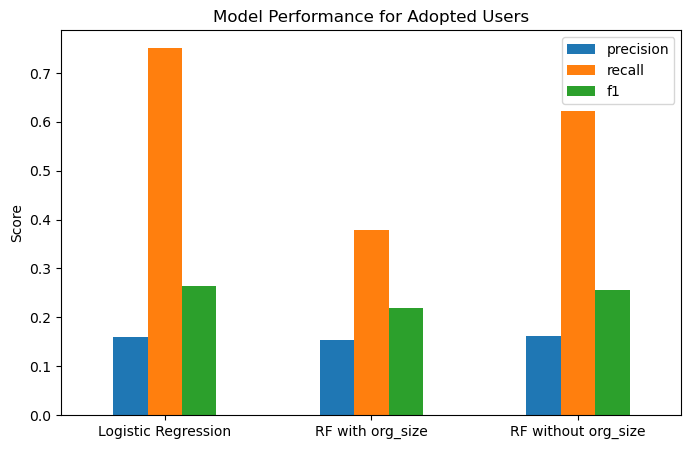

In [68]:
results[['precision', 'recall', 'f1']].plot(
    kind='bar',
    figsize=(8, 5))

plt.ylabel('Score')
plt.xticks(rotation=0)
plt.title('Model Performance for Adopted Users')
plt.legend(loc='upper right')
plt.show()

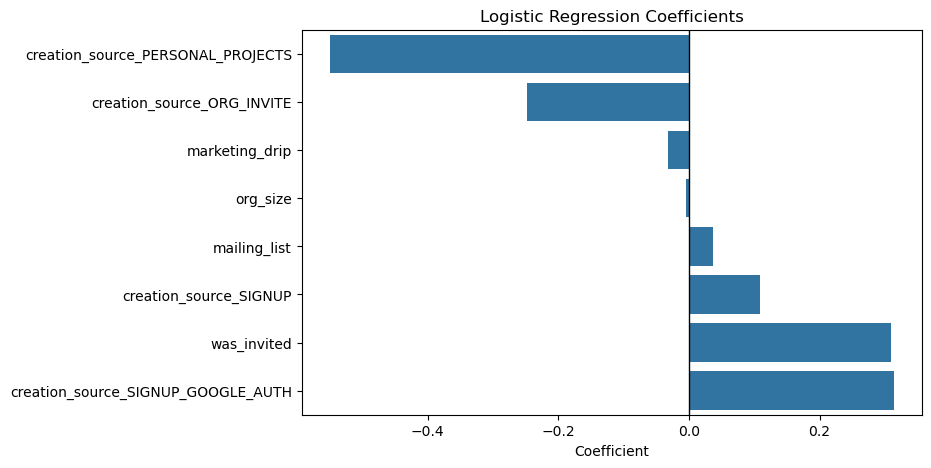

In [70]:
coef_plot = coef_df.sort_values('coefficient')

plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_plot,
    x='coefficient',
    y='feature')

plt.axvline(0, color='black', linewidth=1)
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('')
plt.show()

### Key Takeaways
- Strongest positive association to adoption were Google authentication and being invited by another user.
- Personal Project accounts had the strongest negative association.
- Marketing-related features had weak predictive value.

the relationships are only associations, they're not causal so they don't mean Google authenticated accounts are more likely to adopt, etc.]

### Limitations

The dataset didn't haev much info on user behavior before adoption, so we can't really tell what behaviors lead to adoption. Also, since there was such a high volume of users who didn't adopt, it was harder to get an accurate read on what features might lead to adoption. It's harder to train the model when a user is more likely not to adopt, with little information on why they might, this led to lower precision/recall scores. I didn't have specific activity information to see if a user would be more likely to adopt if they had more active days in the first 30 days of their account, but I could have engineered that score. My hesitation is that might lead to data leakage because all we need for that is 3 days in a 7 day period. Finally, organization data was misleading because some had high adoption rates, but the organization size was relatively small.

### Business recommendations

I'd look specifically into sign up source, Google-authenticated accounts, and invitations because it could be related to trust signals (a little presumptuious, but worth looking into). Personal Project users might need more onboarding help, tutorials, or incentives to find value in the platform. Since marketing emails didn't have a strong impact, I would put less resources into that. Finally, I'd collect more data on user behavior and then test retention strategies to see which might be valuable enough to implement.